#**Unsuperwised Learning**

  it is don't have labels.

Totaly 2 types:

  1.Clustering

  2.Association rule mining  

Clustering:
#k-Means clustering
we cluster the datas based on the similarity.

here K means the number of clusters

we find distance to cluster the datapoints.



Ex(Clustering): we segment customers based on there,

    1.based on there spending

    2.there frequensy of there buying

    3.based on there salary

Ex(Association rule mining): we create relationship between the products based on there relationship.


  


  

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/AI Training/Datasets/Copy of Mall_Customers.csv')

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score,0


In [ ]:
df.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.tail()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.drop("CustomerID", axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Genre']=le.fit_transform(df['Genre'])

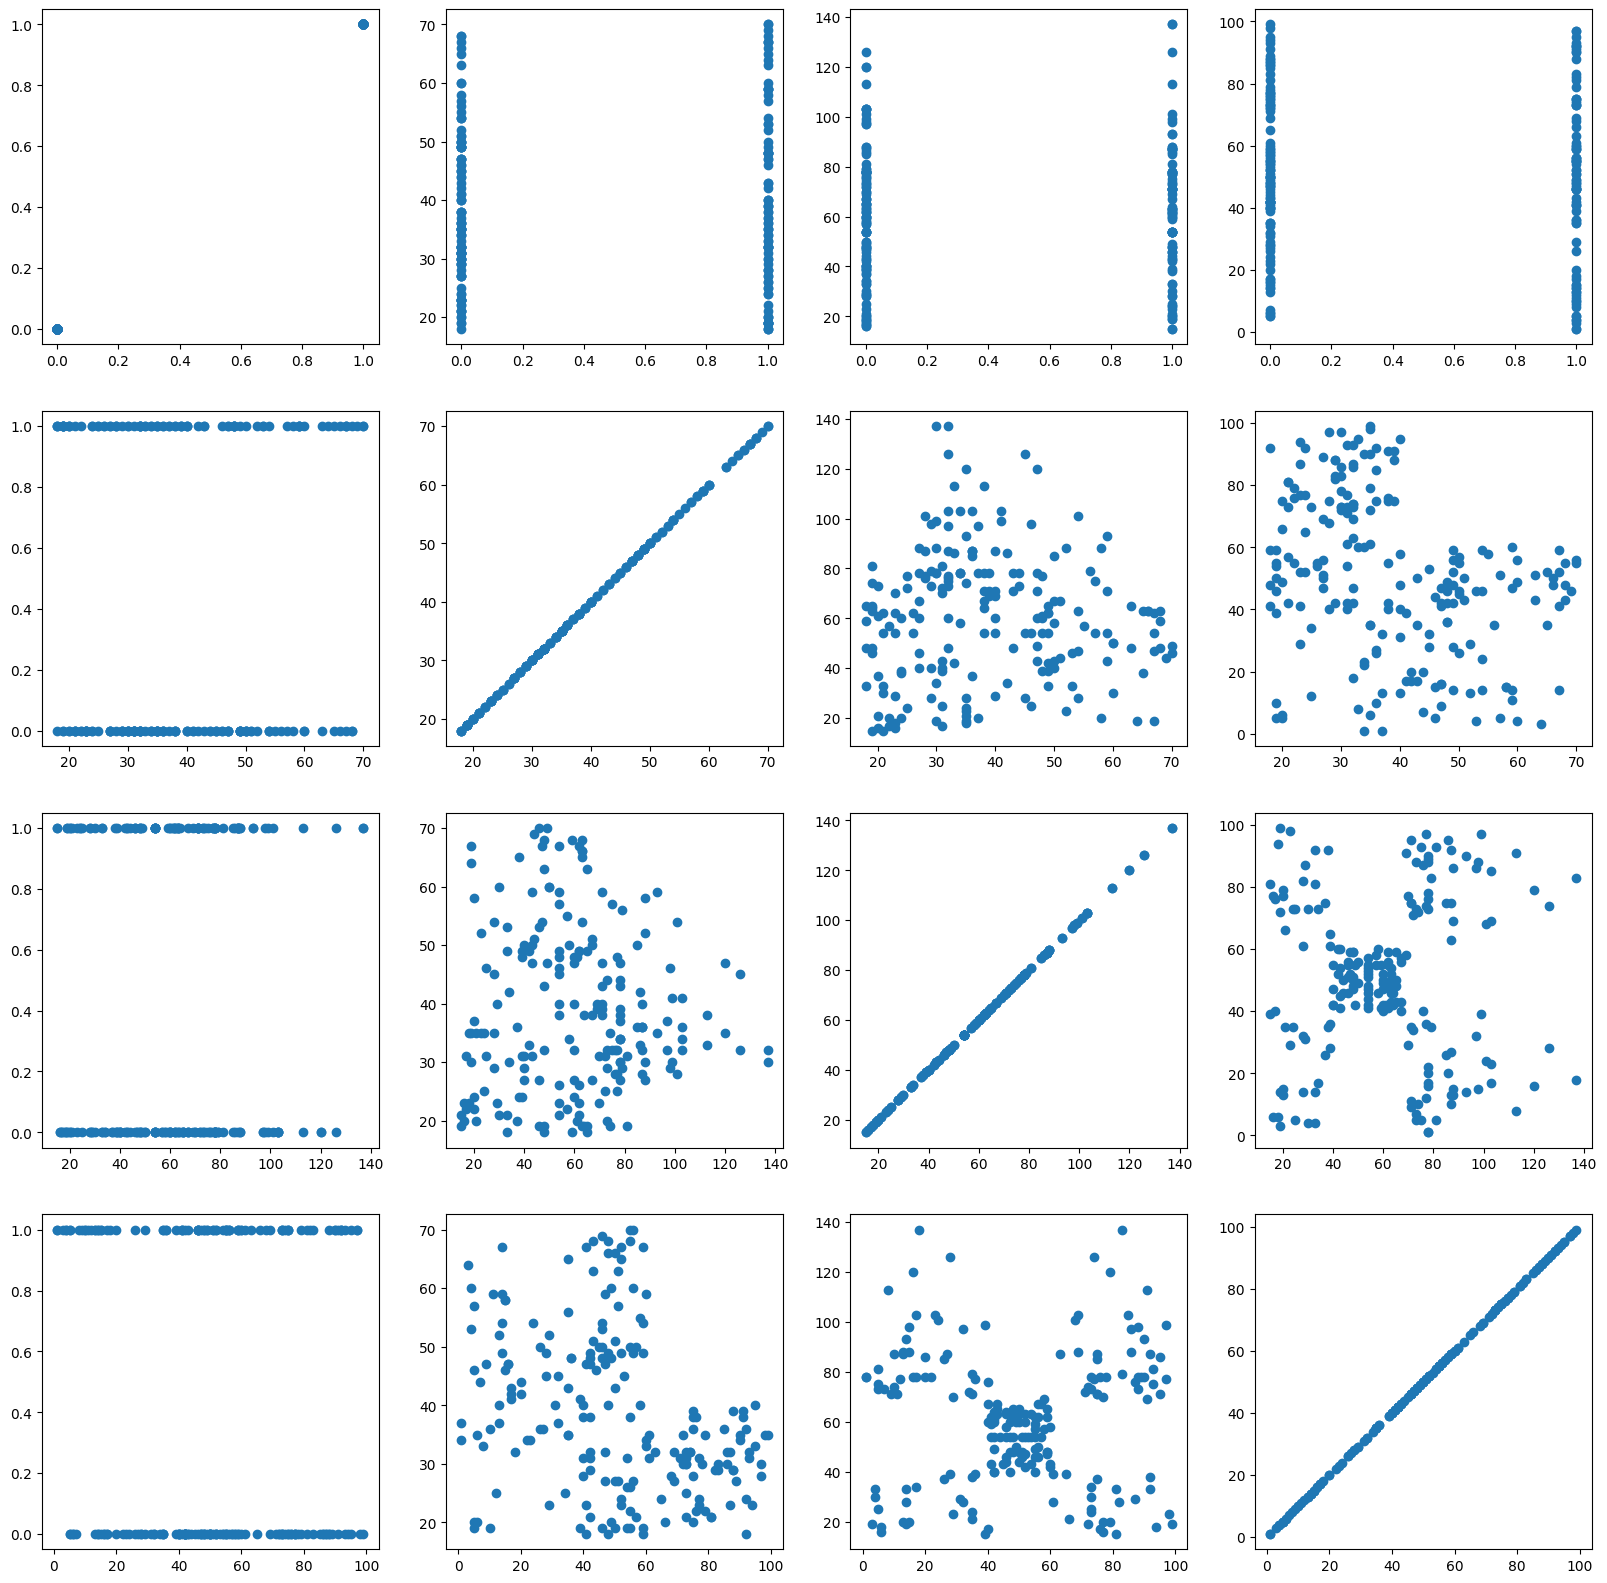

In [ ]:
import matplotlib.pyplot as plt
i=1
plt.figure(figsize=(20,20))
for x in df.columns.to_list():
  for y in df.columns.to_list():
    plt.subplot(4,4,i)
    i+=1
    plt.scatter(df[x],df[y])

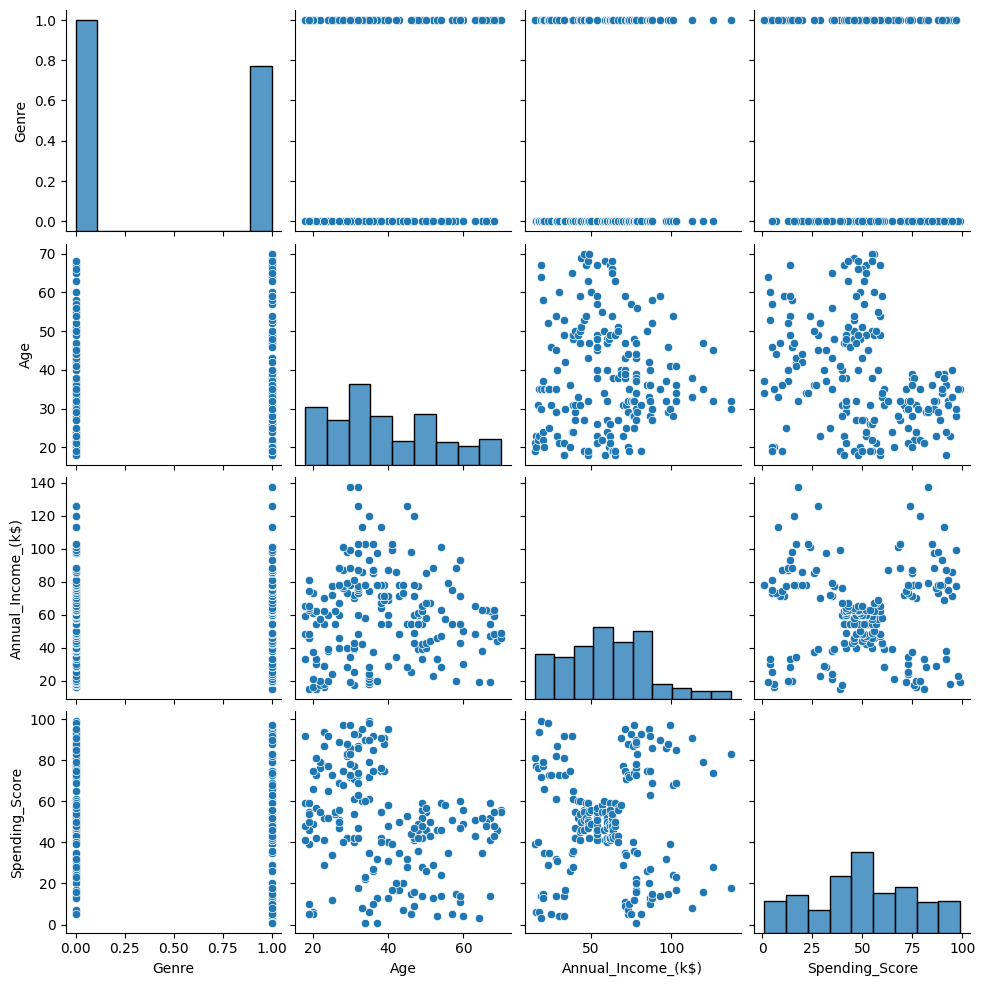

In [ ]:
import seaborn as sns
sns.pairplot(df)

In [ ]:
df.head()

,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
cluster=df.iloc[:,2:].values

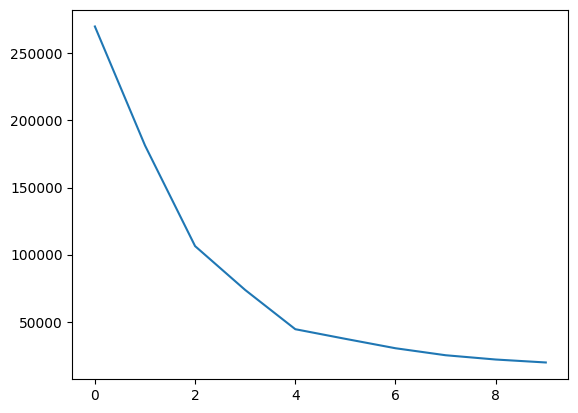

In [ ]:
from sklearn.cluster import KMeans
c=[]
for i in range(1,11):
  model=KMeans(n_clusters=i, init="k-means++", random_state=0, n_init=10, max_iter=300)

  model.fit(cluster)
  c.append(model.inertia_)
plt.plot(c)

In [ ]:
finamodel=KMeans(n_clusters=5, init="k-means++", random_state=0, n_init=10, max_iter=300)

label=finamodel.fit_predict(cluster)


In [ ]:
label

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
finamodel.inertia_

44448.45544793369

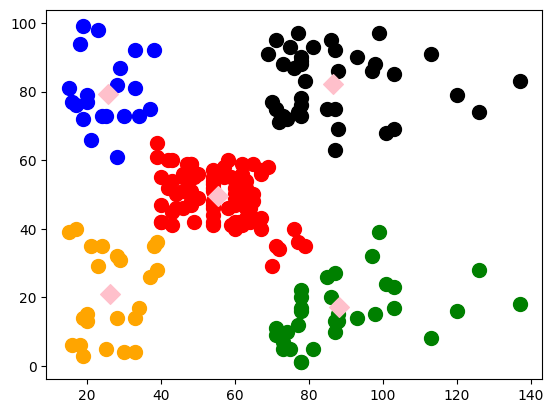

In [ ]:
plt.scatter(cluster[label == 0, 0], cluster[ label == 0, 1], c='green', s=100, label='l1')
plt.scatter(cluster[label == 1, 0], cluster[ label == 1, 1], c='red', s=100, label='l2')
plt.scatter(cluster[label == 2, 0], cluster[ label == 2, 1], c='black', s=100, label='l3')
plt.scatter(cluster[label == 3, 0], cluster[ label == 3, 1], c='blue', s=100, label='l4')
plt.scatter(cluster[label == 4, 0], cluster[ label == 4, 1], c='orange', s=100, label='l5')

plt.scatter(finamodel.cluster_centers_[:,0], finamodel.cluster_centers_[:,1],c='pink', s=100, marker='D')



#DB Scan

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
# j=1
# while True:
i=1
while True:
  model=DBSCAN(eps=i, min_samples=6, metric="euclidean")
  model.fit_predict(cluster)
  label=model.labels_
  ldf=pd.DataFrame({"label":label})
  # print("Running")
  if -1 in ldf['label'].unique():
    if abs(ldf[ldf["label"]==-1].sum().sum()) < 10:
    #if len(ldf['label'].unique())-1 ==5:
        print(i)
        print(len(ldf['label'].unique())-1)
        break
  else:
    if len(ldf['label'].unique()) == 5:
      print(i)
      print(len(ldf['label'].unique()))
      break
  i+=0.01

  # j+=1



13.419999999999758
1


In [ ]:
label

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0, -1, -1,  0, -1, -1, -1, -1, -1, -1])

In [ ]:
1 in ldf['label'].unique()

False

In [ ]:
abs(ldf[ldf["label"]==-1].sum())

,0
label,9


In [ ]:
# -1 in ldf['label'].values

In [ ]:
abs(ldf[ldf["label"]==-1].sum())

,0
label,9


#Hirarchicla clustering

#Distance methods

it is totaly 4 types.

    1.minimun distance
    2.maximum distance
    3.mean distance
    4.ward distance
  
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250912124228594945/_distance_metrics_in_hierarchical_clustering.webp" width=400/>

#1.Minimum distance
  that finds the minimum distance between any two points of the cluster.

    Formula
      D(A,B)=min(d(a,b))
      Where:
      A,B → two clusters
      a∈A, b∈B
  Idea: Find the closest pair of points between clusters.
#2.Max Distance
Find the maximum distance between any two points of the cluster.

Complete linkage uses the maximum distance between points from two clusters.

    Formula
      D(A,B)=max(d(a,b))
      Where:
      A,B → two clusters
      a∈A, b∈B
Idea: Find the farthest pair of points.
#3.Group Average
Find the average distance between every two points of the clusters.
Average linkage uses the average distance between all point pairs in two clusters.

Formula:
$$
D(A,B)=\frac{1}{|A||B|}\sum_{a\in A}\sum_{b\in B} d(a,b)
$$

Idea: Compute all distances between clusters and take the average.
#4.Ward's Method
The similarity of two clusters is based on the increase in squared error when two clusters are merged.

The "distance" Δ between two clusters A and B is calculated using their sizes (cardinality) and the squared Euclidean distance between their centers (centroids):

$$
\Delta(A, B) = \frac{n_A \times n_B}{n_A + n_B} \times \Vert m_A - m_B \Vert^2
$$

#5.Center method

4. Centroid Linkage

Centroid linkage uses the distance between cluster centroids.

Formula:
$$
D(A,B)=d(CA​,CB​)
$$

Where:​

 Ca= centroid of cluster A

 Cb= centroid of cluster B

Idea: Find center point of each cluster and measure distance between centers.


In [ ]:
cluster

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy as sch


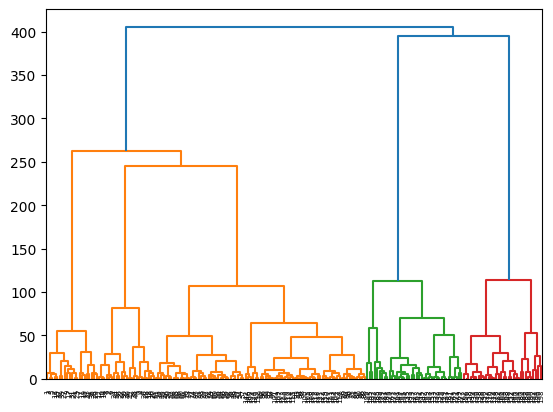

In [ ]:
sch.dendrogram(sch.linkage(cluster, method='ward'))
plt.show()

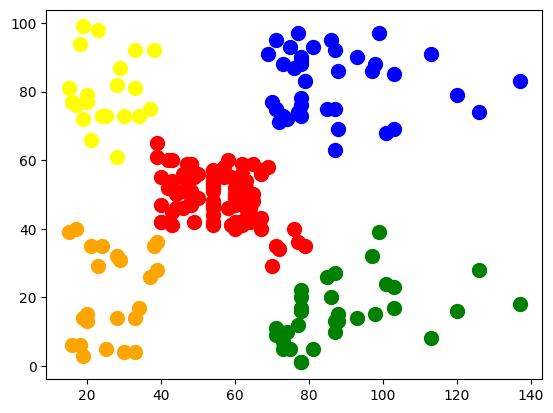

In [ ]:
model=AgglomerativeClustering(n_clusters=5, linkage='ward')
label=model.fit_predict(cluster)

plt.scatter(cluster[label==0, 0], cluster[label==0, 1], c='green', s=100, label='c1')
plt.scatter(cluster[label==1, 0], cluster[label==1, 1], c='red', s=100, label='c2')
plt.scatter(cluster[label==2, 0], cluster[label==2, 1], c='blue', s=100, label='c3')
plt.scatter(cluster[label==3, 0], cluster[label==3, 1], c='yellow', s=100, label='c4')
plt.scatter(cluster[label==4, 0], cluster[label==4, 1], c='orange', s=100, label='c5')

plt.show()

In [ ]:
label

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

#Divisive

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
n_c=[cluster]
n_cluster=5

while len(n_c)<n_cluster:
  model=KMeans(n_clusters=2)
  larg_cluster=max(n_c, key=len)
  largest_index =  np.argmax([len(c) for c in n_c])
  n_c.pop(largest_index)
  labels=model.fit_predict(larg_cluster)


  cluster_1=larg_cluster[labels==0]
  cluster_2=larg_cluster[labels==1]

  n_c.append(cluster_1)
  n_c.append(cluster_2)

print(len(n_c))

5


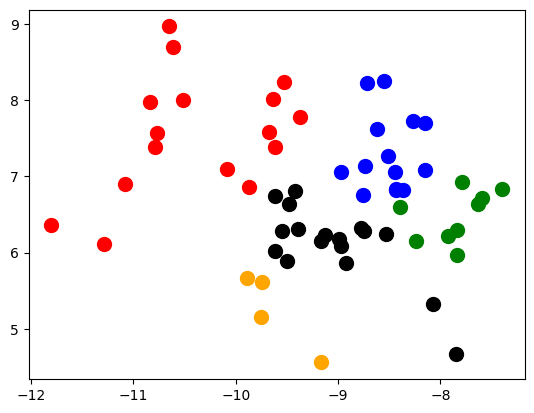

In [ ]:
colors = ['red', 'blue', 'green', 'orange', 'black']
for i, cluster in enumerate(n_c):
  plt.scatter(cluster[:,0], cluster[:,1],c=colors[i],label=f"cluster {i+1}", s=100)
plt.show()